# Bayesian Parameter Estimation with PyMC and PyMCSimMod

This tutorial demonstrates how to use the PyMC integration in `PyMCSimMod` to perform Bayesian parameter estimation on ODE models.

We will cover:
1. Defining and loading an ODE model.
2. Generating synthetic data for parameter estimation.
3. Fitting the model using the high-level `BayesianODEModel` context-manager API.
4. Accessing posterior draws and diagnostics.
5. Projecting and plotting time-course posterior predictive trajectories using `BayesianComputedModel`.

### 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from pymcsimmod.models.jax_model import JaxModel
from pymcsimmod import BayesianODEModel

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Define the Model

We will use a simple one-compartment pharmacokinetic/pharmacodynamic (PK) model representing an exponential decay processes:
$$\frac{dA}{dt} = - k_e \cdot A$$

In [2]:
model_str = """
States = {
    A
};

ke = 0.5;

Initialize {
    A = 1.0;
}
Dynamics {
    dt(A) = - A * ke;
}
End.
"""

model = JaxModel(model_str)

### 3. Generate Synthetic Data

Let's simulate the model with a true value of $k_e = 0.35$ and add some Gaussian noise to create observations.

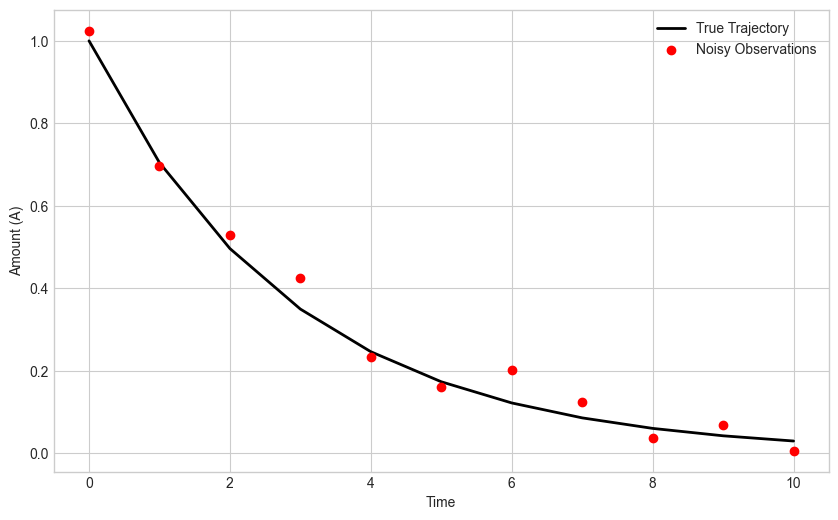

In [3]:
true_ke = 0.35
model.update_constants(ke=true_ke)

times = np.linspace(0, 10, 11)
sim = model.run_model(times)
true_y = sim.states.squeeze()

# Add observational noise
np.random.seed(42)
noise_sigma = 0.05
observed_data = true_y + np.random.normal(0, noise_sigma, size=len(times))

plt.plot(times, true_y, label='True Trajectory', color='black', lw=2)
plt.scatter(times, observed_data, label='Noisy Observations', color='red', zorder=5)
plt.xlabel('Time')
plt.ylabel('Amount (A)')
plt.legend()
plt.show()

### 4. Bayesian Inference with `BayesianODEModel`

We can now define priors for our parameters and define the PyMC probabilistic model using the high-level `BayesianODEModel` API.

In [4]:
# Reset model back to defaults
model.update_constants(reset_to_defaults=True)

# Initialize the wrapper
bayes_model = BayesianODEModel(model, times=times)

with pm.Model() as pm_model:
    # Prior distributions
    ke = pm.HalfNormal("ke", sigma=1.0)
    y0_init = pm.Normal("y0", mu=1.0, sigma=0.2)
    
    # Run the ODE solver inside PyMC context
    predictions = bayes_model.solve(
        params={"ke": ke},
        y0={"A": y0_init},
        observed_vars=["A"]
    )
    
    # Observational noise prior and likelihood
    sigma = pm.HalfNormal("sigma", sigma=0.1)
    pm.Normal("obs", mu=predictions, sigma=sigma, observed=observed_data)
    
    # Sample the model
    idata = pm.sample(draws=1000, tune=1000, chains=2, random_seed=42)

c:\Users\tjzur\models\PyMCSimMod\.venv\Lib\site-packages\pytensor\gradient.py:1327: FutureWarning: MCSimModOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
NUTS[nutpie]: [ke, y0, sigma]
c:\Users\tjzur\models\PyMCSimMod\.venv\Lib\site-packages\pytensor\gradient.py:1327: FutureWarning: MCSimModOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
c:\Users\tjzur\models\PyMCSimMod\.venv\Lib\site-packages\pytensor\link\numba\dispatch\basic.py:234: UserWarning: Numba will use object mode to run MCSimModOp{_n_params=1, _n_y0=1, _output_shape=(11,), _name='MCSimModOp_JaxModel'}'s perform method. Set `pytensor.config.compiler_verbose = True` to

Output()

### 5. Posterior Analysis and Diagnostics

Let's look at the summary diagnostics and plot posterior distributions for $k_e$ and $y_0$.

        mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
y0     1.016  0.037     0.96      1.1       909       948  1.00    0.0012   
ke     0.331  0.021      0.3     0.37       914      1006  1.00   0.00071   
sigma  0.043  0.012    0.028    0.065       880       838  1.00    0.0004   

       mcse_sd  
y0       0.001  
ke      0.0007  
sigma  0.00047  


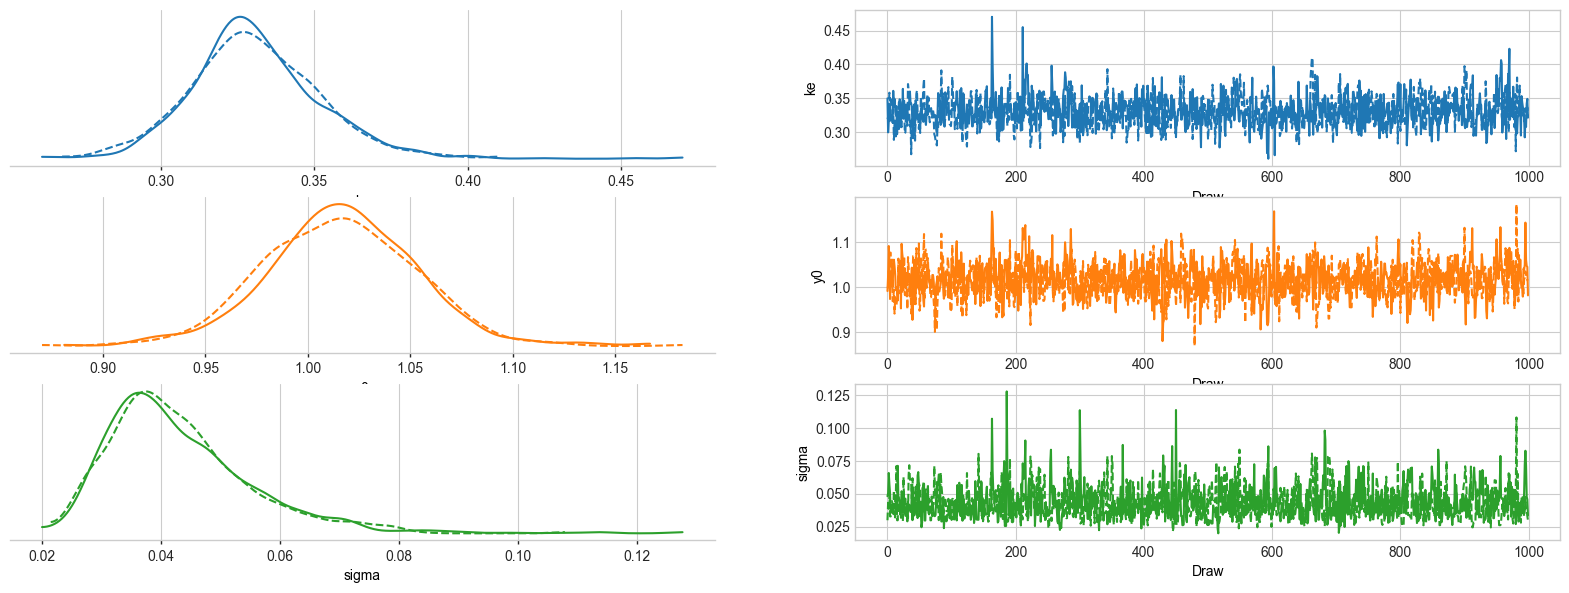

In [6]:
# Print summary table
print(az.summary(idata))

# Plot parameter traces
az.plot_trace_dist(idata, var_names=["ke", "y0", "sigma"])
plt.show()

### 6. Posterior Predictive Time-Course Projections

We can use `BayesianComputedModel` to project and visualize the fitted ODE trajectory uncertainty (highest density intervals) over time.

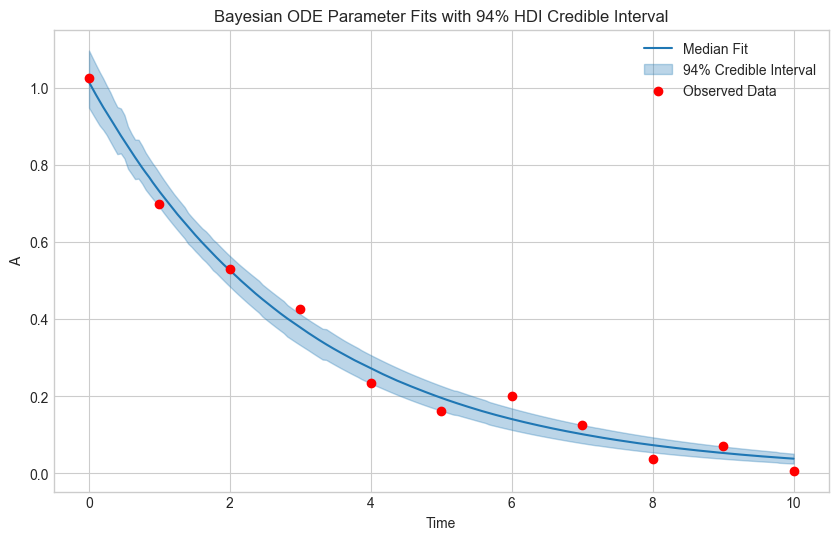

In [7]:
computed = bayes_model.posterior_predictive(idata)

# Plot posterior predictive intervals on a denser time grid
dense_times = np.linspace(0, 10, 200)

fig, ax = plt.subplots(figsize=(10, 6))
computed.plot_predictive(var_name="A", ax=ax, hdi_prob=0.94, num_samples=200, times=dense_times)

# Overlay data points
ax.scatter(times, observed_data, color='red', label='Observed Data', zorder=5)
ax.legend()
ax.set_title("Bayesian ODE Parameter Fits with 94% HDI Credible Interval")
plt.show()